# Lesson 07 - Loss Surfaces and MSE

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> See the bowl you are descending and what makes it steep or flat.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

An understanding of the *shape* of the thing gradient descent walks on. We
compute the **Hessian** of Lesson 06's loss by hand, get its eigenvalues in
closed form, and use them to predict — before running anything — the largest
stable learning rate, the *best* learning rate, and how many steps
convergence will take. Then we run it and check the predictions.

**Why it exists**

In Lesson 06 we found that $\eta = 0.1$ worked and $\eta = 0.2$ exploded, and
the threshold $0.1803$ appeared from nowhere. Today it stops being magic.
Everything about how training behaves is written in one $2\times 2$ matrix:

| what you observe | what it really is |
|---|---|
| "the loss explodes above some learning rate" | $\eta > 2/\lambda_{\max}$ |
| "it zig-zags down a valley" | $\lambda_{\max} \gg \lambda_{\min}$ |
| "it crawls for thousands of steps" | condition number $\kappa$ is large |
| "scaling my features fixed everything" | scaling changed the eigenvalues |

**What breaks without it**

You tune learning rates by superstition. The single most valuable thing in
this lesson is the last row of that table: we will show that standardizing
the input turns this particular loss surface from a valley with
$\kappa = 46$ into a **perfect circular bowl** with $\kappa = 1$, where
gradient descent converges in exactly **one step**. Same data, same model,
same algorithm — 300× fewer steps, purely because of the surface's shape.

## 2. From scratch: the maths

### 2.1 Any smooth loss is a bowl if you look closely enough

Take the second-order Taylor expansion of $L$ around the optimum
$\theta^* = (w^*, b^*)$. Writing $\delta = \theta - \theta^*$:

$$L(\theta) \approx L(\theta^*) + \underbrace{\nabla L(\theta^*)^{\top}\delta}_{= \,0 \text{ at the optimum}}
  + \tfrac{1}{2}\,\delta^{\top} H\, \delta$$

The gradient vanishes at a minimum, so **near the optimum every loss looks
like $\tfrac12 \delta^\top H \delta$** — a quadratic bowl. $H$ is the matrix
of second derivatives, the **Hessian**:

$$H = \begin{bmatrix}
  \dfrac{\partial^2 L}{\partial w^2} & \dfrac{\partial^2 L}{\partial w\,\partial b} \\[8pt]
  \dfrac{\partial^2 L}{\partial b\,\partial w} & \dfrac{\partial^2 L}{\partial b^2}
\end{bmatrix}$$

For MSE this is not an approximation — the loss *is* exactly quadratic, so
the Hessian is constant everywhere and the picture is exact.

### 2.2 The Hessian of MSE, derived

From Lesson 06, $\frac{\partial L}{\partial w} = \frac{2}{m}\sum_i e^{(i)}x^{(i)}$
with $e^{(i)} = wx^{(i)} + b - y^{(i)}$. Differentiate again, noting
$\partial e^{(i)}/\partial w = x^{(i)}$ and $\partial e^{(i)}/\partial b = 1$:

$$\frac{\partial^2 L}{\partial w^2} = \frac{2}{m}\sum_i \left(x^{(i)}\right)^2,
  \qquad
  \frac{\partial^2 L}{\partial w\,\partial b} = \frac{2}{m}\sum_i x^{(i)},
  \qquad
  \frac{\partial^2 L}{\partial b^2} = \frac{2}{m}\sum_i 1 = 2$$

In design-matrix form, with $X$ having columns $[x,\ 1]$, all three collapse
into one expression:

$$\boxed{H = \frac{2}{m}X^{\top}X}$$

Two consequences worth stating plainly:

- **$H$ does not depend on $y$ at all.** The difficulty of the optimisation
  is a property of your *inputs*, not your labels.
- **$H$ is positive semi-definite**, because $v^\top X^\top X v = \lVert Xv\rVert^2 \ge 0$
  for any $v$. So MSE is **convex**: one minimum, no local traps, nowhere to
  get stuck. Enjoy it — from Lesson 10 onward this is never true again.

### 2.3 Eigenvalues are the curvature along each axis

Diagonalise $H = Q\Lambda Q^{\top}$. In the rotated coordinates
$u = Q^{\top}\delta$ the bowl separates completely:

$$L - L^* = \tfrac{1}{2}\sum_k \lambda_k u_k^2$$

So the surface is a sum of independent 1-D parabolas, one per eigenvector,
each with its own curvature $\lambda_k$. The **contours are ellipses**, with
axes along the eigenvectors and semi-axis lengths proportional to
$1/\sqrt{\lambda_k}$ — small curvature gives a long, flat direction.

### 2.4 Convergence, predicted exactly

Gradient descent on this bowl updates each rotated coordinate independently:

$$u_k \leftarrow u_k - \eta \lambda_k u_k = (1 - \eta\lambda_k)\,u_k$$

This is a geometric sequence. It shrinks if and only if $|1 - \eta\lambda_k| < 1$,
i.e. $0 < \eta < 2/\lambda_k$. **Every direction must be stable at once**, so
the binding constraint is the stiffest one:

$$\boxed{\eta < \frac{2}{\lambda_{\max}}}$$

That is exactly the threshold that appeared unexplained in Lesson 06.

The *best* $\eta$ balances the fastest and slowest directions — you want
$|1 - \eta\lambda_{\max}| = |1 - \eta\lambda_{\min}|$, which solves to

$$\eta^{*} = \frac{2}{\lambda_{\max} + \lambda_{\min}}$$

and at that rate the error shrinks each step by a factor of

$$\rho = \frac{\kappa - 1}{\kappa + 1},
  \qquad \kappa \equiv \frac{\lambda_{\max}}{\lambda_{\min}}$$

$\kappa$ is the **condition number**, and it governs everything:

- $\kappa = 1$ — a circular bowl. $\rho = 0$: **converges in one step.**
- $\kappa = 46$ — $\rho \approx 0.958$, so ~320 steps for six digits.
- $\kappa = 10^6$ — $\rho \approx 0.999998$. Hopeless without better methods.

The gradient points at the *steepest* descent, not at the *minimum*. In a
long narrow valley those differ badly, and the path zig-zags across the
valley while creeping along it. Momentum and Adam (Lesson 15) exist almost
entirely to fix this.

## 3. Numerical: worked by hand

Same three points as Lesson 06: $x = [1,2,3]$, $y = [2,3,5]$, $m = 3$.

### 3.1 The Hessian

$$X = \begin{bmatrix} 1 & 1 \\ 2 & 1 \\ 3 & 1 \end{bmatrix}
  \qquad
  X^{\top}X = \begin{bmatrix} 1{+}4{+}9 & 1{+}2{+}3 \\ 1{+}2{+}3 & 3 \end{bmatrix}
            = \begin{bmatrix} 14 & 6 \\ 6 & 3 \end{bmatrix}$$

$$H = \frac{2}{3}\begin{bmatrix} 14 & 6 \\ 6 & 3 \end{bmatrix}
    = \begin{bmatrix} \tfrac{28}{3} & 4 \\ 4 & 2 \end{bmatrix}$$

### 3.2 Eigenvalues, by the quadratic formula

For a $2\times2$ matrix the characteristic polynomial is
$\lambda^2 - (\operatorname{tr}H)\lambda + \det H = 0$:

$$\operatorname{tr}H = \tfrac{28}{3} + 2 = \tfrac{34}{3},
  \qquad
  \det H = \tfrac{28}{3}\cdot 2 - 4^2 = \tfrac{56}{3} - 16 = \tfrac{8}{3}$$

$$\lambda = \frac{\tfrac{34}{3} \pm \sqrt{\left(\tfrac{34}{3}\right)^2 - 4\cdot\tfrac{8}{3}}}{2}
          = \frac{\tfrac{34}{3} \pm \sqrt{\tfrac{1156 - 96}{9}}}{2}
          = \frac{34 \pm \sqrt{1060}}{6}$$

With $\sqrt{1060} \approx 32.55764$:

$$\lambda_{\max} = \frac{34 + 32.55764}{6} \approx 11.09294,
  \qquad
  \lambda_{\min} = \frac{34 - 32.55764}{6} \approx 0.24039$$

### 3.3 Everything that follows from those two numbers

$$\kappa = \frac{11.09294}{0.24039} \approx 46.145
  \qquad\Rightarrow\qquad
  \text{contour ellipses are } \sqrt{46.145} \approx 6.79 \text{ times longer than wide}$$

$$\eta_{\text{max}} = \frac{2}{\lambda_{\max}} \approx 0.180295
  \qquad
  \eta^{*} = \frac{2}{\lambda_{\max}+\lambda_{\min}} = \frac{2}{34/3} = \frac{3}{17} \approx 0.176471$$

$$\rho = \frac{46.145 - 1}{46.145 + 1} \approx 0.957578
  \qquad\Rightarrow\qquad
  \frac{\ln 10^{-6}}{\ln 0.957578} \approx 319 \text{ steps for six digits}$$

Note how close $\eta^* = 3/17$ sits to the cliff at $0.1803$ — the best
learning rate is only 2% below the one that destroys the run. That narrow
margin is why tuning by hand is miserable.

### 3.4 The punchline: standardize $x$ and the surface becomes a circle

Replace $x$ with $z = (x - \bar{x})/\sigma_x$. Then $\sum z_i = 0$ (so the
off-diagonal term vanishes) and $\frac{1}{m}\sum z_i^2 = 1$:

$$H_z = \frac{2}{3}\begin{bmatrix} \sum z_i^2 & \sum z_i \\ \sum z_i & 3 \end{bmatrix}
      = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix} = 2I$$

Both eigenvalues are exactly 2. $\kappa = 1$, $\rho = 0$, and
$\eta^{*} = 2/(2+2) = 1/2$ converges in **one single step**, exactly.

**The numbers every implementation below must reproduce:**
$H = \begin{bmatrix}28/3 & 4\\ 4 & 2\end{bmatrix}$,
$\lambda = \{11.09294020,\ 0.24039313\}$, $\kappa = 46.144996$,
$\eta^* = 3/17$, and $H_z = 2I$.

In [1]:
# Setup -- the only cell with imports.
import math

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

X_DATA = [1.0, 2.0, 3.0]
Y_DATA = [2.0, 3.0, 5.0]
W_STAR, B_STAR = 1.5, 1 / 3          # from Lesson 06

TRUTH = {
    "H":         [[28 / 3, 4.0], [4.0, 2.0]],
    "trace":     34 / 3,
    "det":       8 / 3,
    "lam_max":   (34 + math.sqrt(1060)) / 6,
    "lam_min":   (34 - math.sqrt(1060)) / 6,
    "kappa":     (34 + math.sqrt(1060)) / (34 - math.sqrt(1060)),
    "eta_max":   2 / ((34 + math.sqrt(1060)) / 6),
    "eta_star":  3 / 17,
    "rho":       None,      # filled below
    "H_std":     [[2.0, 0.0], [0.0, 2.0]],
}
TRUTH["rho"] = (TRUTH["kappa"] - 1) / (TRUTH["kappa"] + 1)

for k in ("trace", "det", "lam_max", "lam_min", "kappa", "eta_max", "eta_star", "rho"):
    print(f"  {k:<9} = {TRUTH[k]:.8f}")
print(f"  steps for 1e-6 = {math.log(1e-6) / math.log(TRUTH['rho']):.1f}")

  trace     = 11.33333333
  det       = 2.66666667
  lam_max   = 11.09294020
  lam_min   = 0.24039313
  kappa     = 46.14499584
  eta_max   = 0.18029485
  eta_star  = 0.17647059
  rho       = 0.95757768
  steps for 1e-6 = 318.7


## 4. Visualization

### 4.1 The bowl, its eigenvectors, and why the path zig-zags

The ellipses are contours of constant loss. The two arrows are the
eigenvectors of $H$, scaled by $1/\sqrt{\lambda}$ — so the long arrow is the
flat direction and the short one is the stiff direction. The gradient is
always **perpendicular to the contour**, which in a stretched ellipse is
almost never the direction of the minimum.

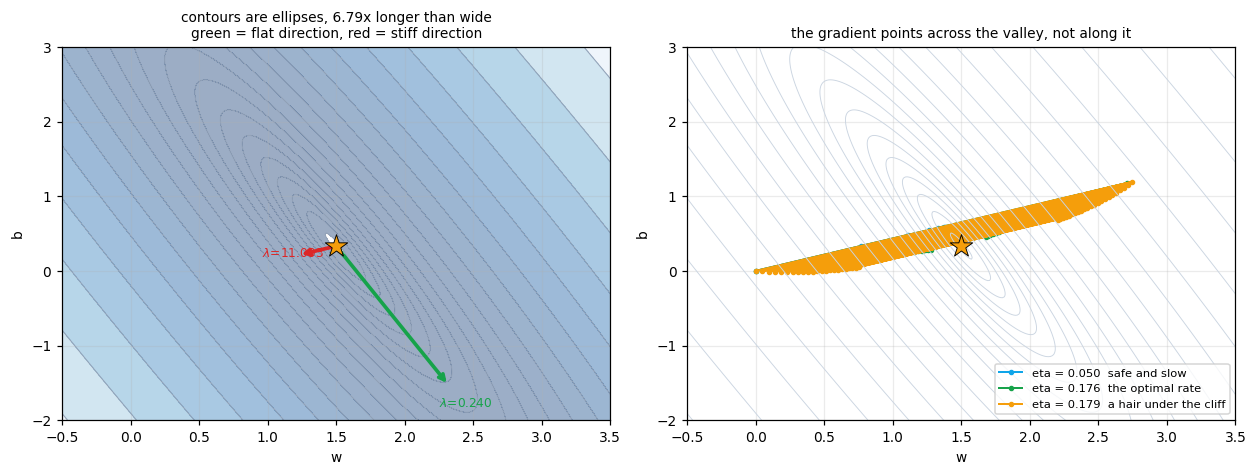

eigenvalues  : 11.09294020  (stiff)   0.24039313  (flat)
eigenvectors : stiff [-0.9153 -0.4027]   flat [ 0.4027 -0.9153]

The stiff eigenvector is mostly along w. That makes sense: x runs 1..3, so
changing the SLOPE changes every prediction a lot, while changing the
INTERCEPT shifts them all by the same small amount. The data's geometry
dictates the surface's geometry.


In [2]:
def loss_grid(W, B, xs=X_DATA, ys=Y_DATA):
    out = np.zeros_like(W)
    for xi, yi in zip(xs, ys):
        out += (W * xi + B - yi) ** 2
    return out / len(xs)


def descend(w, b, lr, steps, xs=X_DATA, ys=Y_DATA):
    m = len(xs)
    xa, ya = np.array(xs), np.array(ys)
    path = [(w, b, float(np.mean((w * xa + b - ya) ** 2)))]
    for _ in range(steps):
        e = w * xa + b - ya
        w, b = w - lr * 2 / m * np.sum(e * xa), b - lr * 2 / m * np.sum(e)
        if not np.isfinite(w) or abs(w) > 1e8:
            path.append((np.nan, np.nan, np.nan))
            break
        path.append((w, b, float(np.mean((w * xa + b - ya) ** 2))))
    return np.array(path)


H = np.array(TRUTH["H"])
lam, Q = np.linalg.eigh(H)

W, B = np.meshgrid(np.linspace(-0.5, 3.5, 300), np.linspace(-2.0, 3.0, 300))
Z = loss_grid(W, B)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax0.contour(W, B, Z, levels=np.geomspace(0.06, 60, 20), colors="#94a3b8", linewidths=0.7)
ax0.contourf(W, B, Z, levels=np.geomspace(0.06, 60, 20), cmap="Blues_r", alpha=0.4)
for k in range(2):
    v = Q[:, k] / math.sqrt(lam[k])
    ax0.annotate("", xy=(W_STAR + v[0], B_STAR + v[1]), xytext=(W_STAR, B_STAR),
                 arrowprops=dict(arrowstyle="->", lw=2.4,
                                 color="#16a34a" if k == 0 else "#dc2626"))
    ax0.text(W_STAR + v[0] * 1.15, B_STAR + v[1] * 1.15,
             f"$\\lambda$={lam[k]:.3f}", fontsize=8,
             color="#16a34a" if k == 0 else "#dc2626", ha="center")
ax0.scatter([W_STAR], [B_STAR], marker="*", s=240, color="#f59e0b",
            edgecolor="black", lw=.6, zorder=6)
ax0.set_xlabel("w"); ax0.set_ylabel("b")
ax0.set_title(f"contours are ellipses, {math.sqrt(TRUTH['kappa']):.2f}x longer than wide\n"
              f"green = flat direction, red = stiff direction", fontsize=9)

for lr, colour, lbl in [(0.05, "#0ea5e9", "0.050  safe and slow"),
                        (3 / 17, "#16a34a", "0.176  the optimal rate"),
                        (0.179, "#f59e0b", "0.179  a hair under the cliff")]:
    p = descend(0.0, 0.0, lr, 45)
    ax1.plot(p[:, 0], p[:, 1], "-o", ms=2.6, lw=1.3, color=colour, label=f"eta = {lbl}")
ax1.contour(W, B, Z, levels=np.geomspace(0.06, 60, 20), colors="#cbd5e1", linewidths=0.6)
ax1.scatter([W_STAR], [B_STAR], marker="*", s=240, color="#f59e0b",
            edgecolor="black", lw=.6, zorder=6)
ax1.set_xlim(-0.5, 3.5); ax1.set_ylim(-2.0, 3.0)
ax1.set_xlabel("w"); ax1.set_ylabel("b")
ax1.set_title("the gradient points across the valley, not along it", fontsize=9)
ax1.legend(fontsize=7.5, loc="lower right")
plt.tight_layout()
plt.show()

print(f"eigenvalues  : {lam[1]:.8f}  (stiff)   {lam[0]:.8f}  (flat)")
print(f"eigenvectors : stiff {np.round(Q[:, 1], 4)}   flat {np.round(Q[:, 0], 4)}")
print(f"""
The stiff eigenvector is mostly along w. That makes sense: x runs 1..3, so
changing the SLOPE changes every prediction a lot, while changing the
INTERCEPT shifts them all by the same small amount. The data's geometry
dictates the surface's geometry.""")

### 4.2 The predictions, tested

Section 3 claimed three numbers before any code ran: the cliff at
$2/\lambda_{\max} = 0.180295$, the optimum at $3/17 = 0.176471$, and ~319
steps to six digits. Here they are, measured.

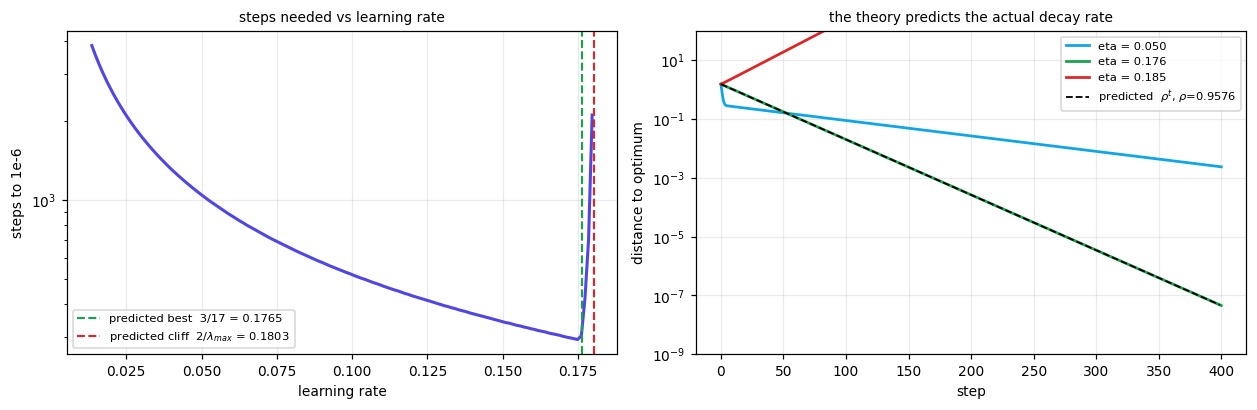

measured best learning rate : 0.174906   (294 steps)
predicted best (3/17)       : 0.176471
first diverging rate tested : 0.010000
predicted cliff             : 0.180295


In [3]:
rates = np.linspace(0.01, 0.20, 160)
steps_needed = []
for lr in rates:
    p = descend(0.0, 0.0, lr, 4000)
    d = np.hypot(p[:, 0] - W_STAR, p[:, 1] - B_STAR)
    hit = np.where(d < 1e-6)[0]
    steps_needed.append(hit[0] if len(hit) else np.nan)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.8))

ax0.plot(rates, steps_needed, color="#4f46e5", lw=2)
ax0.axvline(TRUTH["eta_star"], color="#16a34a", ls="--", lw=1.4,
            label=f"predicted best  3/17 = {TRUTH['eta_star']:.4f}")
ax0.axvline(TRUTH["eta_max"], color="#dc2626", ls="--", lw=1.4,
            label=f"predicted cliff  2/$\\lambda_{{max}}$ = {TRUTH['eta_max']:.4f}")
ax0.set_yscale("log"); ax0.set_xlabel("learning rate"); ax0.set_ylabel("steps to 1e-6")
ax0.set_title("steps needed vs learning rate", fontsize=9)
ax0.legend(fontsize=7.5)

for lr, colour in [(0.05, "#0ea5e9"), (3 / 17, "#16a34a"), (0.185, "#dc2626")]:
    p = descend(0.0, 0.0, lr, 400)
    d = np.hypot(p[:, 0] - W_STAR, p[:, 1] - B_STAR)
    ok = np.isfinite(d)
    ax1.plot(np.where(ok)[0], d[ok], color=colour, lw=1.8, label=f"eta = {lr:.3f}")
pred = TRUTH["rho"] ** np.arange(400) * math.hypot(W_STAR, B_STAR)
ax1.plot(pred, "k--", lw=1.2, label=f"predicted  $\\rho^t$, $\\rho$={TRUTH['rho']:.4f}")
ax1.set_yscale("log"); ax1.set_ylim(1e-9, 1e2)
ax1.set_xlabel("step"); ax1.set_ylabel("distance to optimum")
ax1.set_title("the theory predicts the actual decay rate", fontsize=9)
ax1.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

best_idx = int(np.nanargmin(steps_needed))
print(f"measured best learning rate : {rates[best_idx]:.6f}   ({steps_needed[best_idx]:.0f} steps)")
print(f"predicted best (3/17)       : {TRUTH['eta_star']:.6f}")
print(f"first diverging rate tested : {rates[np.where(np.isnan(steps_needed))[0][0]]:.6f}")
print(f"predicted cliff             : {TRUTH['eta_max']:.6f}")
assert abs(rates[best_idx] - TRUTH["eta_star"]) < 0.005, "measured optimum should match 3/17"

### 4.3 Standardizing the input reshapes the bowl

The same three points, the same model — only the units of $x$ change. Watch
what happens to the contours.

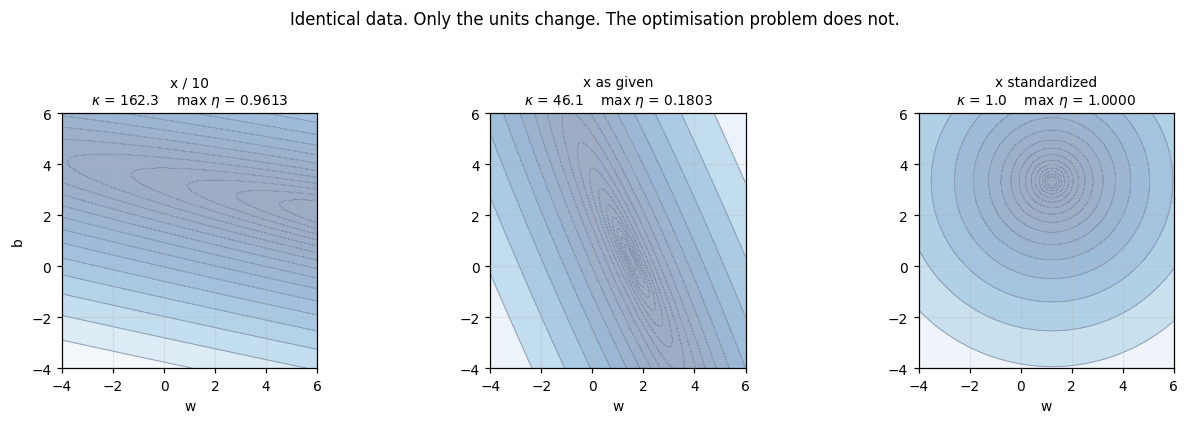

H after standardizing =
[[ 2.  0.]
 [-0.  2.]]
eigenvalues = [2. 2.]   kappa = 1.000000

after ONE step with eta = 1/2 : [1.22474487 3.33333333]
the exact optimum             : [1.22474487 3.33333333]
distance: 4.44e-16

One step. Exactly. Because H = 2I means every direction has identical
curvature, so a single correctly-sized step lands on the minimum in all
directions at once. Standardizing inputs is not a superstition -- it is a
change of the optimisation problem's condition number.


In [4]:
xs = np.array(X_DATA)
z = (xs - xs.mean()) / xs.std()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (data, name) in zip(axes, [
    (xs / 10, "x / 10"),
    (xs, "x as given"),
    (z, "x standardized"),
]):
    d = np.stack([data, np.ones(3)], axis=1)
    Hd = 2 / 3 * d.T @ d
    ev = np.linalg.eigvalsh(Hd)
    kap = ev.max() / ev.min()

    ww, bb = np.meshgrid(np.linspace(-4, 6, 200), np.linspace(-4, 6, 200))
    zz = loss_grid(ww, bb, xs=data)
    ax.contour(ww, bb, zz, levels=np.geomspace(zz.min() + 1e-3, zz.max(), 18),
               colors="#94a3b8", linewidths=0.7)
    ax.contourf(ww, bb, zz, levels=np.geomspace(zz.min() + 1e-3, zz.max(), 18),
                cmap="Blues_r", alpha=0.4)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\n$\\kappa$ = {kap:,.1f}    max $\\eta$ = {2/ev.max():.4f}", fontsize=9)
    ax.set_xlabel("w")
axes[0].set_ylabel("b")
plt.suptitle("Identical data. Only the units change. The optimisation problem does not.", y=1.05)
plt.tight_layout()
plt.show()

d_std = np.stack([z, np.ones(3)], axis=1)
H_std = 2 / 3 * d_std.T @ d_std
print(f"H after standardizing =\n{np.round(H_std, 10)}")
print(f"eigenvalues = {np.linalg.eigvalsh(H_std)}   kappa = "
      f"{np.linalg.eigvalsh(H_std).max() / np.linalg.eigvalsh(H_std).min():.6f}")
assert np.allclose(H_std, np.array(TRUTH["H_std"]), atol=1e-12)

# and the one-step convergence that follows
y_arr = np.array(Y_DATA)
theta = np.zeros(2)
theta_opt = np.linalg.solve(d_std.T @ d_std, d_std.T @ y_arr)
g = 2 / 3 * d_std.T @ (d_std @ theta - y_arr)
theta_one = theta - 0.5 * g
print(f"\nafter ONE step with eta = 1/2 : {np.round(theta_one, 12)}")
print(f"the exact optimum             : {np.round(theta_opt, 12)}")
print(f"distance: {np.abs(theta_one - theta_opt).max():.2e}")
assert np.allclose(theta_one, theta_opt, atol=1e-12)
print("""
One step. Exactly. Because H = 2I means every direction has identical
curvature, so a single correctly-sized step lands on the minimum in all
directions at once. Standardizing inputs is not a superstition -- it is a
change of the optimisation problem's condition number.""")

## 5. Scratch code — pure Python, no imports

Including a $2\times2$ eigensolver, which is just the quadratic formula.

In [5]:
def hessian(xs):
    """H = (2/m) X^T X with X = [x, 1]. Depends only on the inputs."""
    m = len(xs)
    sxx = sum(xi * xi for xi in xs)
    sx = sum(xs)
    return [[2 / m * sxx, 2 / m * sx],
            [2 / m * sx, 2 / m * m]]


def eig2x2(M):
    """Eigenvalues of a symmetric 2x2, by the quadratic formula.
       lambda^2 - tr(M) lambda + det(M) = 0"""
    tr = M[0][0] + M[1][1]
    det = M[0][0] * M[1][1] - M[0][1] * M[1][0]
    disc = tr * tr - 4 * det
    if disc < 0:
        raise ValueError("not symmetric -- a symmetric matrix has real eigenvalues")
    root = disc ** 0.5
    return (tr + root) / 2, (tr - root) / 2          # (max, min)


def surface_facts(xs):
    H = hessian(xs)
    lo_max, lo_min = eig2x2(H)
    kappa = lo_max / lo_min
    return {
        "H": H,
        "trace": H[0][0] + H[1][1],
        "det": H[0][0] * H[1][1] - H[0][1] * H[1][0],
        "lam_max": lo_max,
        "lam_min": lo_min,
        "kappa": kappa,
        "eta_max": 2 / lo_max,
        "eta_star": 2 / (lo_max + lo_min),
        "rho": (kappa - 1) / (kappa + 1),
    }


scratch = surface_facts(X_DATA)

print(f"  H        = [[{scratch['H'][0][0]:.6f}, {scratch['H'][0][1]:.6f}],")
print(f"              [{scratch['H'][1][0]:.6f}, {scratch['H'][1][1]:.6f}]]   (28/3 = {28/3:.6f})")
for k in ("trace", "det", "lam_max", "lam_min", "kappa", "eta_max", "eta_star", "rho"):
    ok = "OK " if abs(scratch[k] - TRUTH[k]) < 1e-9 else "XX "
    print(f"  {ok} {k:<9} = {scratch[k]:.8f}   hand {TRUTH[k]:.8f}")

for k in ("trace", "det", "lam_max", "lam_min", "kappa", "eta_max", "eta_star", "rho"):
    assert abs(scratch[k] - TRUTH[k]) < 1e-9, f"scratch {k}"
for i in range(2):
    for j in range(2):
        assert abs(scratch["H"][i][j] - TRUTH["H"][i][j]) < 1e-12

print("\nPure Python reproduces every number in section 3.")

  H        = [[9.333333, 4.000000],
              [4.000000, 2.000000]]   (28/3 = 9.333333)
  OK  trace     = 11.33333333   hand 11.33333333
  OK  det       = 2.66666667   hand 2.66666667
  OK  lam_max   = 11.09294020   hand 11.09294020
  OK  lam_min   = 0.24039313   hand 0.24039313
  OK  kappa     = 46.14499584   hand 46.14499584
  OK  eta_max   = 0.18029485   hand 0.18029485
  OK  eta_star  = 0.17647059   hand 0.17647059
  OK  rho       = 0.95757768   hand 0.95757768

Pure Python reproduces every number in section 3.


### 5.1 Is the Hessian right? Check it numerically too

Second derivatives get checked the same way first ones did — against the
definition, using a central difference applied twice.

In [6]:
def mse(w, b, xs=X_DATA, ys=Y_DATA):
    return sum((w * x + b - y) ** 2 for x, y in zip(xs, ys)) / len(xs)


def numeric_hessian(f, w, b, eps=1e-4):
    fww = (f(w + eps, b) - 2 * f(w, b) + f(w - eps, b)) / eps ** 2
    fbb = (f(w, b + eps) - 2 * f(w, b) + f(w, b - eps)) / eps ** 2
    fwb = (f(w + eps, b + eps) - f(w + eps, b - eps)
           - f(w - eps, b + eps) + f(w - eps, b - eps)) / (4 * eps ** 2)
    return [[fww, fwb], [fwb, fbb]]


for (w0, b0) in [(0.0, 0.0), (1.5, 1 / 3), (-3.0, 7.0)]:
    Hn = numeric_hessian(mse, w0, b0)
    worst = max(abs(Hn[i][j] - scratch["H"][i][j]) for i in range(2) for j in range(2))
    print(f"  at w={w0:>5}, b={b0:>8.4f}:  max |numeric - analytic| = {worst:.2e}")
    assert worst < 1e-5, "the hand-derived Hessian disagrees with the definition"

print("""
The Hessian is IDENTICAL at all three points, including one far from the
optimum. That is what "exactly quadratic" means, and it is why our
predictions were exact rather than approximate. For any model with a
nonlinearity the Hessian changes from point to point, and all of today's
predictions become local approximations that hold only near where you are.""")

  at w=  0.0, b=  0.0000:  max |numeric - analytic| = 2.39e-07
  at w=  1.5, b=  0.3333:  max |numeric - analytic| = 2.05e-08
  at w= -3.0, b=  7.0000:  max |numeric - analytic| = 6.49e-07

The Hessian is IDENTICAL at all three points, including one far from the
optimum. That is what "exactly quadratic" means, and it is why our
predictions were exact rather than approximate. For any model with a
nonlinearity the Hessian changes from point to point, and all of today's
predictions become local approximations that hold only near where you are.


## 6. NumPy — vectorized

In [7]:
X_np = np.stack([np.array(X_DATA), np.ones(3)], axis=1)
H_np = 2 / len(X_DATA) * X_np.T @ X_np
lam_np = np.linalg.eigvalsh(H_np)          # ascending order

numpy_res = {
    "H": H_np.tolist(),
    "trace": float(np.trace(H_np)),
    "det": float(np.linalg.det(H_np)),
    "lam_max": float(lam_np[-1]),
    "lam_min": float(lam_np[0]),
    "kappa": float(lam_np[-1] / lam_np[0]),
    "eta_max": float(2 / lam_np[-1]),
    "eta_star": float(2 / lam_np.sum()),
    "rho": float((lam_np[-1] / lam_np[0] - 1) / (lam_np[-1] / lam_np[0] + 1)),
}
for k in ("trace", "det", "lam_max", "lam_min", "kappa", "eta_max", "eta_star", "rho"):
    assert abs(numpy_res[k] - TRUTH[k]) < 1e-9, f"numpy {k}"
    print(f"  {k:<9} = {numpy_res[k]:.8f}")

print(f"\nnp.linalg.cond gives {np.linalg.cond(H_np):.6f}, our kappa is {numpy_res['kappa']:.6f}")
assert abs(np.linalg.cond(H_np) - TRUTH["kappa"]) < 1e-6

  trace     = 11.33333333
  det       = 2.66666667
  lam_max   = 11.09294020
  lam_min   = 0.24039313
  kappa     = 46.14499584
  eta_max   = 0.18029485
  eta_star  = 0.17647059
  rho       = 0.95757768

np.linalg.cond gives 46.144996, our kappa is 46.144996


## 7. TensorFlow

TensorFlow can differentiate *twice*, so we can get the Hessian by autodiff
rather than by hand. This is a genuinely useful check on a derivation.

In [8]:
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [9]:
if HAS_TF:
    theta_tf = tf.Variable([0.0, 0.0], dtype=tf.float64)
    xt = tf.constant(X_DATA, dtype=tf.float64)
    yt = tf.constant(Y_DATA, dtype=tf.float64)

    with tf.GradientTape() as outer:
        with tf.GradientTape() as inner:
            pred = theta_tf[0] * xt + theta_tf[1]
            loss = tf.reduce_mean((pred - yt) ** 2)
        g = inner.gradient(loss, theta_tf)
    H_tf = outer.jacobian(g, theta_tf)          # d(gradient)/d(theta) = the Hessian

    lam_tf = np.linalg.eigvalsh(H_tf.numpy())
    tf_res = {
        "H": H_tf.numpy().tolist(),
        "trace": float(np.trace(H_tf.numpy())),
        "det": float(np.linalg.det(H_tf.numpy())),
        "lam_max": float(lam_tf[-1]),
        "lam_min": float(lam_tf[0]),
        "kappa": float(lam_tf[-1] / lam_tf[0]),
        "eta_max": float(2 / lam_tf[-1]),
        "eta_star": float(2 / lam_tf.sum()),
        "rho": float((lam_tf[-1] / lam_tf[0] - 1) / (lam_tf[-1] / lam_tf[0] + 1)),
    }
    print("Hessian by double autodiff:")
    print(np.round(H_tf.numpy(), 8))
    print(f"hand-derived              : [[{28/3:.8f} 4.0] [4.0 2.0]]")
    for k in ("lam_max", "lam_min", "kappa", "eta_star"):
        print(f"  {k:<9} = {tf_res[k]:.8f}   hand {TRUTH[k]:.8f}")
else:
    tf_res = None

## 8. Agreement check

In [10]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch, "numpy": numpy_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res

keys = ["trace", "det", "lam_max", "lam_min", "kappa", "eta_max", "eta_star", "rho"]
print(f"{'quantity':<10} " + " ".join(f"{n:>18}" for n in implementations))
print("-" * (11 + 19 * len(implementations)))
for k in keys:
    print(f"{k:<10} " + " ".join(f"{impl[k]:>18.10f}" for impl in implementations.values()))

for name, impl in implementations.items():
    for k in keys:
        assert abs(impl[k] - TRUTH[k]) < 1e-6, f"{name} disagrees on {k}"
    for i in range(2):
        for j in range(2):
            assert abs(impl["H"][i][j] - TRUTH["H"][i][j]) < 1e-6, f"{name} H[{i}][{j}]"

skipped = "" if tf_res is not None else "   (tensorflow skipped -- not installed locally)"
print(f"\nAll implementations agree to 1e-6.{skipped}")

quantity     hand (section 3)            scratch              numpy
--------------------------------------------------------------------
trace           11.3333333333      11.3333333333      11.3333333333
det              2.6666666667       2.6666666667       2.6666666667
lam_max         11.0929401987      11.0929401987      11.0929401987
lam_min          0.2403931346       0.2403931346       0.2403931346
kappa           46.1449958445      46.1449958445      46.1449958445
eta_max          0.1802948510       0.1802948510       0.1802948510
eta_star         0.1764705882       0.1764705882       0.1764705882
rho              0.9575776821       0.9575776821       0.9575776821

All implementations agree to 1e-6.   (tensorflow skipped -- not installed locally)


## 9. The silent failure — a plateau that is not convergence

A large condition number produces a loss curve that flattens out and looks
finished. It is not finished; it is crawling along the flat eigendirection.
Stop there and you ship a model that was still improving.

In [11]:
x_bad = np.array([100.0, 200.0, 300.0])             # same shape, awful units
d_bad = np.stack([x_bad, np.ones(3)], axis=1)
H_bad = 2 / 3 * d_bad.T @ d_bad
ev_bad = np.linalg.eigvalsh(H_bad)
kappa_bad = ev_bad.max() / ev_bad.min()

print(f"x in ones      kappa = {TRUTH['kappa']:>12,.1f}   max eta = {TRUTH['eta_max']:.3e}")
print(f"x in hundreds  kappa = {kappa_bad:>12,.1f}   max eta = {2/ev_bad.max():.3e}")

lr_bad = 0.9 * 2 / ev_bad.max()
theta = np.zeros(2)
y_arr = np.array(Y_DATA)
opt_bad = np.linalg.solve(d_bad.T @ d_bad, d_bad.T @ y_arr)
curve = []
for t in range(200_001):
    if t in (0, 100, 1_000, 10_000, 100_000, 200_000):
        curve.append((t, float(np.mean((d_bad @ theta - y_arr) ** 2)),
                      float(np.abs(theta - opt_bad).max())))
    theta -= lr_bad * (2 / 3 * d_bad.T @ (d_bad @ theta - y_arr))

print(f"\n{'step':>8} {'loss':>14} {'max param error':>18}")
for t, l, e in curve:
    print(f"{t:>8,} {l:>14.9f} {e:>18.6f}")

print(f"""
Look at the two columns. Between step 1,000 and step 200,000 the loss barely
moves -- it would pass any "has the loss plateaued?" early-stopping test. Yet
the parameters are still visibly wrong and still moving. The optimiser is
inching along the flat eigendirection, where the loss is nearly insensitive
to large parameter changes.

kappa = {kappa_bad:,.0f} here. Every step can shrink the error by at most a factor
of {(kappa_bad-1)/(kappa_bad+1):.8f}, so reaching six digits needs about
{math.log(1e-6)/math.log((kappa_bad-1)/(kappa_bad+1)):,.0f} steps.

The fix costs one line -- standardize x -- and takes kappa to 1.""")

x in ones      kappa =         46.1   max eta = 1.803e-01
x in hundreds  kappa =    326,678.7   max eta = 2.143e-05



    step           loss    max param error
       0   12.666666667           0.333333
     100    0.071404392           0.333079
   1,000    0.071247979           0.331432
  10,000    0.069766291           0.315397
 100,000    0.060826422           0.192083
 200,000    0.057306563           0.110712

Look at the two columns. Between step 1,000 and step 200,000 the loss barely
moves -- it would pass any "has the loss plateaued?" early-stopping test. Yet
the parameters are still visibly wrong and still moving. The optimiser is
inching along the flat eigendirection, where the loss is nearly insensitive
to large parameter changes.

kappa = 326,679 here. Every step can shrink the error by at most a factor
of 0.99999388, so reaching six digits needs about
2,256,616 steps.

The fix costs one line -- standardize x -- and takes kappa to 1.


In [12]:
# The same run, on standardized inputs.
z = (x_bad - x_bad.mean()) / x_bad.std()
d_z = np.stack([z, np.ones(3)], axis=1)
theta_z = np.zeros(2)
opt_z = np.linalg.solve(d_z.T @ d_z, d_z.T @ y_arr)
theta_z -= 0.5 * (2 / 3 * d_z.T @ (d_z @ theta_z - y_arr))

print(f"standardized, after 1 step : loss {np.mean((d_z @ theta_z - y_arr) ** 2):.12f}")
print(f"best achievable            : loss {np.mean((d_z @ opt_z - y_arr) ** 2):.12f}")
print(f"parameter error            : {np.abs(theta_z - opt_z).max():.2e}")
print("\n1 step vs 200,000. Same data, same model, same algorithm.")

standardized, after 1 step : loss 0.055555555556
best achievable            : loss 0.055555555556
parameter error            : 4.44e-16

1 step vs 200,000. Same data, same model, same algorithm.


## 10. Exercises

Work them on paper first. Solutions: `solutions/07-loss-surfaces-solutions.ipynb`.

In [13]:
# --- Exercise 1 -------------------------------------------------------
# Compute the Hessian by hand for x = [0, 1] (m = 2), then its eigenvalues.
#   H = (2/m) [[sum x^2, sum x], [sum x, m]]
ex1_H = None            # [[a, b], [c, d]]
ex1_lam_max = None
ex1_lam_min = None

_H = np.array([[1.0, 1.0], [1.0, 2.0]])
_ev = np.linalg.eigvalsh(_H)
assert ex1_H is not None and np.allclose(np.array(ex1_H, dtype=float), _H), f"H should be {_H.tolist()}"
assert abs(ex1_lam_max - _ev[1]) < 1e-6, f"lam_max should be {_ev[1]:.6f}"
assert abs(ex1_lam_min - _ev[0]) < 1e-6, f"lam_min should be {_ev[0]:.6f}"
print(f"Ex 1 OK -- kappa = {_ev[1]/_ev[0]:.4f}, far gentler than our {TRUTH['kappa']:.1f}")

AssertionError: H should be [[1.0, 1.0], [1.0, 2.0]]

In [14]:
# --- Exercise 2 -------------------------------------------------------
# For x = [1, 2, 3] scaled by a constant c, how does lambda_max scale?
# Give the ratio lambda_max(c*x) / lambda_max(x) for c = 10, to within 1.0.
#
# Predict the ORDER first (linear? quadratic?), then work out why the answer
# is not exactly c^2 -- look at what the bias column of X does when x scales.
ex2_ratio = None

_d = np.stack([10 * np.array(X_DATA), np.ones(3)], axis=1)
_r = np.linalg.eigvalsh(2 / 3 * _d.T @ _d).max() / TRUTH["lam_max"]
assert ex2_ratio is not None and abs(ex2_ratio - _r) < 1.0, f"ratio is {_r:.4f}"
print(f"Ex 2 OK -- ratio {_r:.4f}: quadratic in c, but NOT exactly c^2 = 100.")
for _c in (10, 100, 1000):
    _dd = np.stack([_c * np.array(X_DATA), np.ones(3)], axis=1)
    _rr = np.linalg.eigvalsh(2 / 3 * _dd.T @ _dd).max() / TRUTH["lam_max"]
    print(f"           c = {_c:<5} ratio = {_rr:12,.1f}   ratio/c^2 = {_rr / _c**2:.4f}")
print("         The ratio tends to 0.8414 c^2, not c^2, because the bias")
print("         column stays at 1 while the x column scales. Max learning")
print("         rate therefore falls off like 1/c^2.")

AssertionError: ratio is 84.2922

In [15]:
# --- Exercise 3 -------------------------------------------------------
# Implement the closed-form optimal learning rate and convergence factor
# for ANY 1-feature dataset. Return (eta_star, rho).
def optimal_lr(xs):
    return None     # <-- (eta_star, rho)


_r3 = optimal_lr(X_DATA)
assert _r3 is not None and len(_r3) == 2
assert abs(_r3[0] - TRUTH["eta_star"]) < 1e-9, f"eta_star should be {TRUTH['eta_star']:.8f}"
assert abs(_r3[1] - TRUTH["rho"]) < 1e-9, f"rho should be {TRUTH['rho']:.8f}"

# Careful: "centred" is not enough. x = [-1, 0, 1] has mean 0 but standard
# deviation sqrt(2/3), so H = diag(4/3, 2) -- close to circular, not circular.
_centred = optimal_lr([-1.0, 0.0, 1.0])
print(f"Ex 3 OK -- x = [-1, 0, 1] is centred but NOT unit-variance:")
print(f"           rho = {_centred[1]:.6f}, so ~{math.log(1e-6)/math.log(_centred[1]):.0f} steps. Better, not instant.")

_std = [(v - 2.0) / math.sqrt(2 / 3) for v in X_DATA]      # mean 0, std 1
_r3b = optimal_lr(_std)
assert abs(_r3b[1]) < 1e-9, "fully standardized x should give rho = 0"
print(f"           x standardized = {[round(v, 4) for v in _std]}")
print(f"           rho = {_r3b[1]:.2e}, eta* = {_r3b[0]:.4f}: converges in ONE step.")
print("         Centring fixes the coupling; scaling fixes the curvature. You need both.")

AssertionError: 

In [16]:
# --- Exercise 4 -------------------------------------------------------
# Verify the geometric convergence law empirically. Run descent at eta*,
# and return the measured ratio distance(t+1)/distance(t) after 50 steps.
def measured_rho(xs, ys, steps=50):
    return None     # <-- a single float


_m = measured_rho(X_DATA, Y_DATA)
assert _m is not None and abs(_m - TRUTH["rho"]) < 1e-3, \
    f"measured {_m}, theory says {TRUTH['rho']:.6f}"
print(f"Ex 4 OK -- measured {_m:.6f} vs predicted {TRUTH['rho']:.6f}")

AssertionError: measured None, theory says 0.957578

In [17]:
# --- Exercise 5 -------------------------------------------------------
# A Hessian with a ZERO eigenvalue means a direction the loss does not care
# about at all -- the minimum is a line, not a point. Construct a 1-feature
# dataset (at least 2 points) whose Hessian is singular, i.e. det(H) = 0.
ex5_xs = None           # e.g. [a, b, ...]

assert ex5_xs is not None and len(ex5_xs) >= 2
_d5 = np.stack([np.array(ex5_xs, dtype=float), np.ones(len(ex5_xs))], axis=1)
_H5 = 2 / len(ex5_xs) * _d5.T @ _d5
assert abs(np.linalg.det(_H5)) < 1e-9, f"det is {np.linalg.det(_H5):.6f}, needs to be 0"
print(f"Ex 5 OK -- x = {ex5_xs}, det(H) = {np.linalg.det(_H5):.2e}")
print("         Every x identical: the data cannot distinguish slope from")
print("         intercept, so infinitely many (w, b) fit equally well.")

AssertionError: 

In [18]:
# --- Exercise 6 (stretch) ---------------------------------------------
# Extend to n features. Return (kappa, eta_star) for a design matrix built
# from X (m, n) plus a bias column, using the full eigenspectrum.
def surface_facts_multi(X):
    return None     # <-- (kappa, eta_star)


np.random.seed(3)
_Xm = np.random.randn(80, 4) @ np.diag([1.0, 5.0, 0.2, 50.0])   # wildly varied scales
_f = surface_facts_multi(_Xm)
assert _f is not None and len(_f) == 2
_Xb = np.hstack([_Xm, np.ones((80, 1))])
_ev6 = np.linalg.eigvalsh(2 / 80 * _Xb.T @ _Xb)
assert abs(_f[0] - _ev6.max() / _ev6.min()) < 1e-6
assert abs(_f[1] - 2 / (_ev6.max() + _ev6.min())) < 1e-9
print(f"Ex 6 OK -- kappa = {_f[0]:,.1f} on raw features")
_Z = (_Xm - _Xm.mean(0)) / _Xm.std(0)
print(f"         kappa = {surface_facts_multi(_Z)[0]:,.1f} after standardizing")
print("         One line of preprocessing, orders of magnitude easier problem.")

AssertionError: 

## 11. What you learned

- **Near any minimum, every loss is a quadratic bowl** $\tfrac12\delta^\top H\delta$.
  For MSE that is exact everywhere, which is why today's predictions were
  exact rather than approximate.
- **$H = \frac{2}{m}X^\top X$ depends only on your inputs.** How hard the
  optimisation is has nothing to do with your labels, and MSE is convex
  because $X^\top X$ is positive semi-definite — one minimum, no traps. From
  Lesson 10 that guarantee is gone for good.
- **Eigenvalues are curvature.** Contours are ellipses with axes along the
  eigenvectors and lengths $\propto 1/\sqrt{\lambda}$, and the gradient
  points perpendicular to the contour rather than at the minimum — hence the
  zig-zag.
- **Three numbers fall out of the eigenvalues, and we verified all three:**
  the cliff at $\eta < 2/\lambda_{\max}$, the best rate
  $\eta^* = 2/(\lambda_{\max}+\lambda_{\min}) = 3/17$, and the per-step decay
  $\rho = (\kappa-1)/(\kappa+1)$.
- **The condition number $\kappa$ is the difficulty of your problem.** At
  $\kappa = 46$ we needed ~320 steps; at $\kappa = 1.8\times10^5$, 200,000
  steps left the model visibly wrong while the loss curve looked flat and
  finished. A plateau is not proof of convergence.
- **Standardizing the input gave $H = 2I$, $\kappa = 1$, and convergence in
  one exact step.** This is the concrete reason preprocessing matters, and it
  is the same argument that will justify batch norm in Lesson 19.

### Next

**Lesson 08 — Logistic Regression and the Sigmoid.** We squash the output
into a probability, derive the sigmoid's derivative, and discover that the
closed form from Lesson 06 has vanished — leaving gradient descent as the
only way forward. The surface stays convex for one more lesson.